In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3579178.0650697174


## Single Convolution Layers


### Kernel 1 Stride 1 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2859/2859 [00:00<00:00, 59737.74it/s]
Computing layer execution times: 3000it [00:00, 324159.83it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 2859
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.6732 seconds


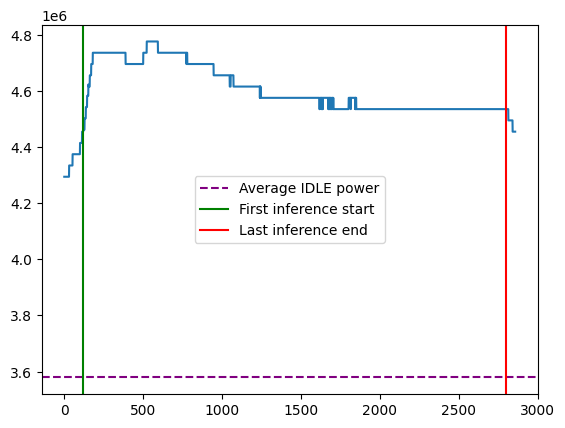

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 534215.50it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,1.747000e+03,1.747000e+03,3000.000000
mean,1500.500000,4.608916e+06,1.029738e+06,0.816979
std,866.169729,8.262556e+04,8.262556e+04,0.115955
min,1.000000,4.454208e+06,8.750299e+05,0.381344
25%,750.750000,4.534464e+06,9.552859e+05,0.804736
50%,1500.500000,4.574592e+06,9.954139e+05,0.826864
75%,2250.250000,4.694976e+06,1.115798e+06,0.855008
max,3000.000000,4.775232e+06,1.196054e+06,3.931040


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt    1747
layer_power_excluding_idle_power_micro_watt    1747
layer_run_time                                 3000
dtype: int64

<Axes: >

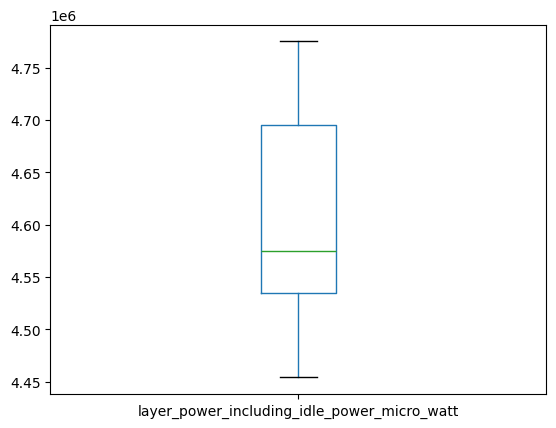

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 2 Stride 2 Output 3

In [11]:
model_name = 'conv_k1_s2_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1471/1471 [00:00<00:00, 68028.99it/s]
Computing layer execution times: 3000it [00:00, 457377.49it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s2_o3: 1471
Number of TensorRT layers in conv_k1_s2_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 1.648978 seconds


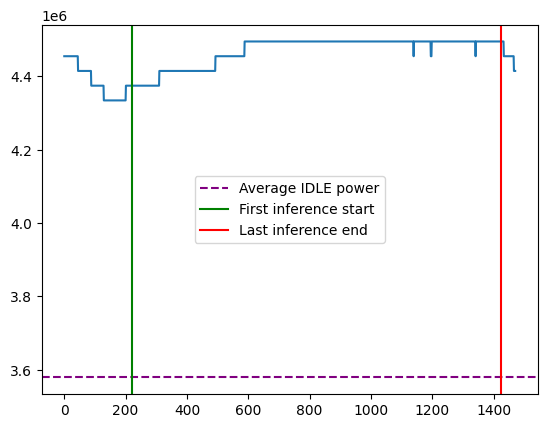

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 982502.69it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,6.830000e+02,683.000000,3000.000000
mean,1500.500000,4.470247e+06,891069.384418,0.315634
std,866.169729,3.965092e+04,39650.922313,0.030667
min,1.000000,4.373952e+06,794773.934930,0.223872
25%,750.750000,4.454208e+06,875029.934930,0.308888
50%,1500.500000,4.494336e+06,915157.934930,0.312128
75%,2250.250000,4.494336e+06,915157.934930,0.319680
max,3000.000000,4.494336e+06,915157.934930,1.508768


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     683
layer_power_excluding_idle_power_micro_watt     683
layer_run_time                                 3000
dtype: int64

<Axes: >

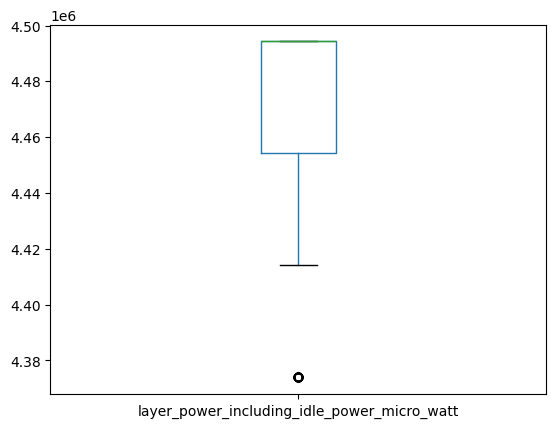

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 3 Stride 3 Output 3

In [18]:
model_name = 'conv_k1_s3_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1285/1285 [00:00<00:00, 105653.08it/s]
Computing layer execution times: 3000it [00:00, 475382.98it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s3_o3: 1285
Number of TensorRT layers in conv_k1_s3_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 1.368119 seconds


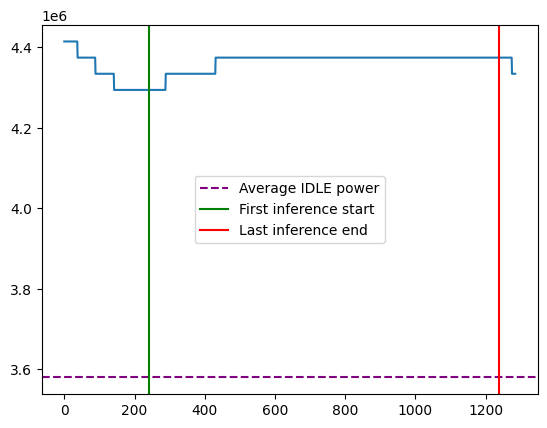

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 731649.73it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,4.970000e+02,497.000000,3000.000000
mean,1500.500000,4.366685e+06,787507.295091,0.234826
std,866.169729,1.954785e+04,19547.849706,0.064445
min,1.000000,4.293696e+06,714517.934930,0.130816
25%,750.750000,4.373952e+06,794773.934930,0.225272
50%,1500.500000,4.373952e+06,794773.934930,0.228768
75%,2250.250000,4.373952e+06,794773.934930,0.238248
max,3000.000000,4.373952e+06,794773.934930,2.862304


In [23]:
metrics_df_k3.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     497
layer_power_excluding_idle_power_micro_watt     497
layer_run_time                                 3000
dtype: int64

<Axes: >

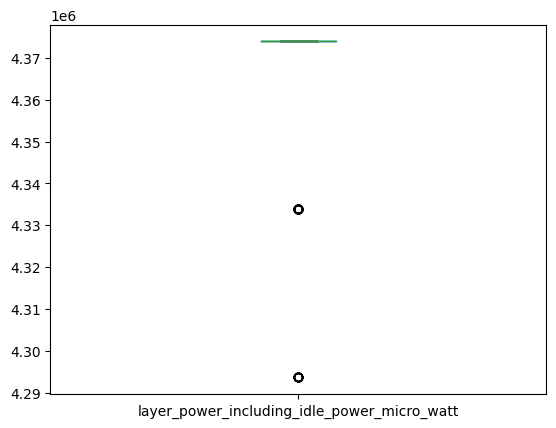

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 4 Output 3

In [25]:
model_name = 'conv_k1_s4_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1251/1251 [00:00<00:00, 107980.04it/s]
Computing layer execution times: 3000it [00:00, 497741.77it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s4_o3: 1251
Number of TensorRT layers in conv_k1_s4_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 1.341596 seconds


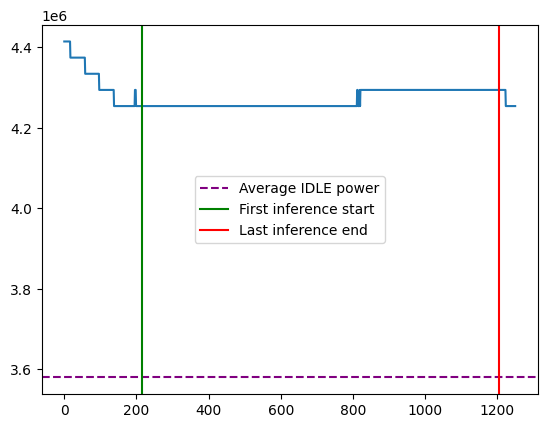

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1185054.81it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,5.160000e+02,516.000000,3000.000000
mean,1500.500000,4.269744e+06,690565.562837,0.232483
std,866.169729,1.970271e+04,19702.714995,0.037869
min,1.000000,4.253568e+06,674389.934930,0.102400
25%,750.750000,4.253568e+06,674389.934930,0.223552
50%,1500.500000,4.253568e+06,674389.934930,0.228048
75%,2250.250000,4.293696e+06,714517.934930,0.238064
max,3000.000000,4.293696e+06,714517.934930,1.790592


In [30]:
metrics_df_k4.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     516
layer_power_excluding_idle_power_micro_watt     516
layer_run_time                                 3000
dtype: int64

<Axes: >

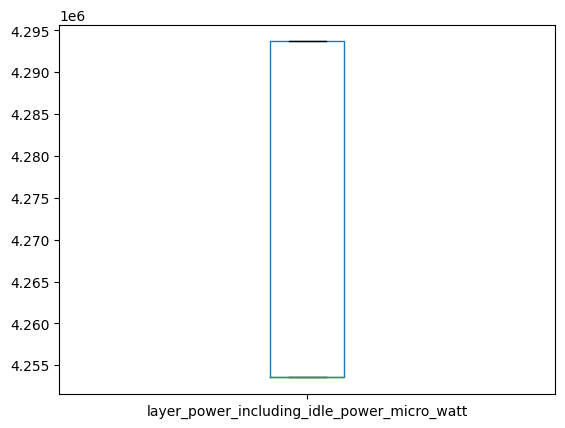

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 1 Stride 5 Output 3

In [32]:
model_name = 'conv_k1_s5_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/f'{model_name}_layerwise_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies(data)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1274/1274 [00:00<00:00, 46374.86it/s]
Computing layer execution times: 3000it [00:00, 294737.00it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s5_o3: 1274
Number of TensorRT layers in conv_k1_s5_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 1.307009 seconds


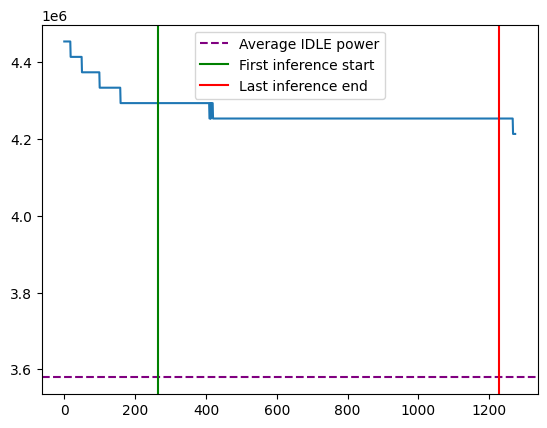

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[2999][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1132983.25it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,4.900000e+02,490.000000,3000.000000
mean,1500.500000,4.259956e+06,680777.657379,0.226191
std,866.169729,1.469572e+04,14695.722907,0.024286
min,1.000000,4.253568e+06,674389.934930,0.125248
25%,750.750000,4.253568e+06,674389.934930,0.217856
50%,1500.500000,4.253568e+06,674389.934930,0.222400
75%,2250.250000,4.253568e+06,674389.934930,0.232584
max,3000.000000,4.293696e+06,714517.934930,1.378752


In [37]:
metrics_df_k5.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     490
layer_power_excluding_idle_power_micro_watt     490
layer_run_time                                 3000
dtype: int64

<Axes: >

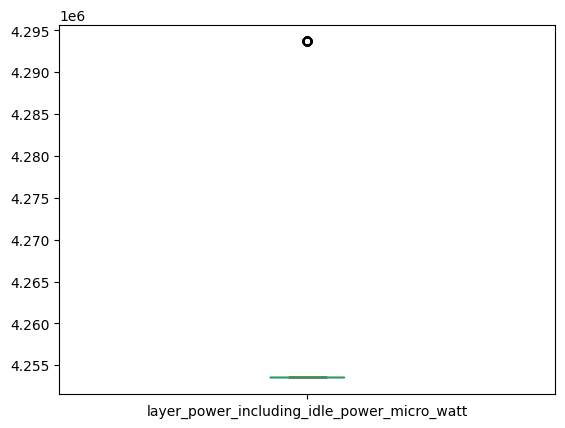

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Strides Plot

Text(0.5, 0, 'Stride size')

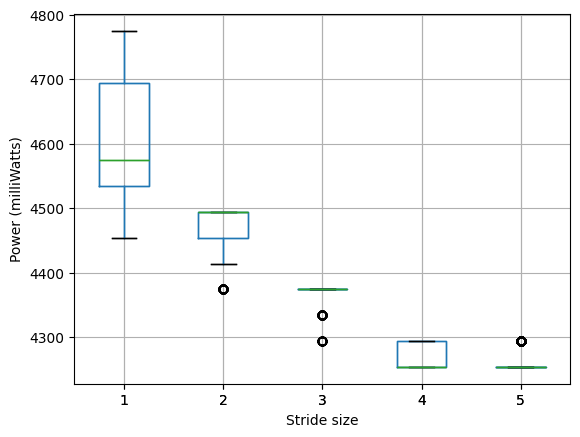

In [39]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3,
    ],
    axis=1,
)


# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (milliWatts)')
df.boxplot().set_xlabel('Stride size')

Text(0.5, 0, 'Stride size')

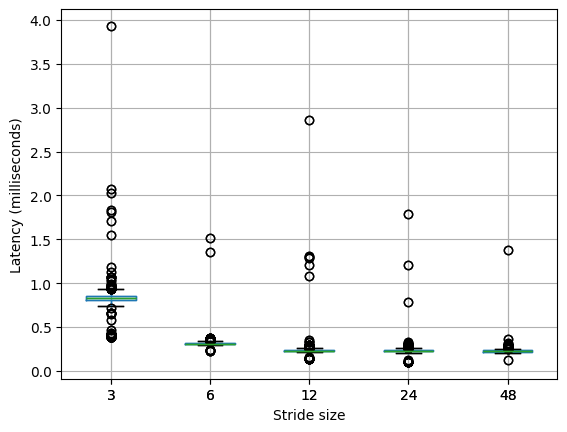

In [40]:
df = pd.concat(
    [
        metrics_df_k1["layer_run_time"],
        metrics_df_k2["layer_run_time"],
        metrics_df_k3["layer_run_time"],
        metrics_df_k4["layer_run_time"],
        metrics_df_k5["layer_run_time"],
    ],
    axis=1,
)

# set column names (will be displayed as plot labels)
df.columns = ['3', '6', '12', '24', '48']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Latency (milliseconds)')
df.boxplot().set_xlabel('Stride size')

Text(0.5, 0, 'Stride size')

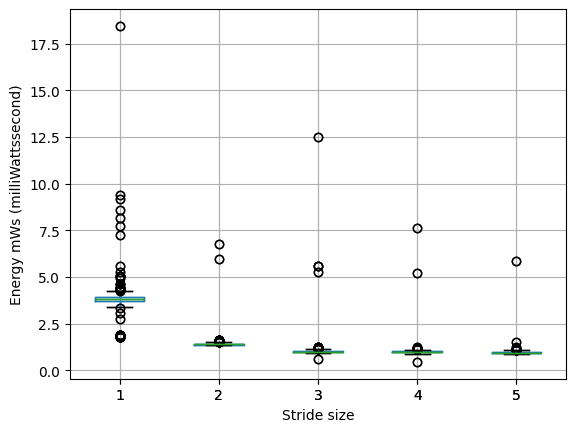

In [41]:
df = pd.concat(
    [   # microwatts converted to milliwatts * millseconds converted to seconds
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k1["layer_run_time"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k2["layer_run_time"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k3["layer_run_time"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k4["layer_run_time"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3 * metrics_df_k5["layer_run_time"] * 1e-3,
    ],
    axis=1,
)


# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']

# use pandas' boxplot method
df.boxplot().set_ylabel('Energy mWs (milliWattssecond)')
df.boxplot().set_xlabel('Stride size')